# Forward data exploration
The goal of this notebook is to do exploration on forward data and understand which features should be used for the model training. This also helps to define the final views for the model, that simplify querying data from the NHL database for the tuned model. 

## Historical career data
Since the NHL dataset is not overly large, we need to be aware of overfitting. Just adding all stats to the model is unlikely to produce a good result. One way to recude the number of features while also keeping sensitivity to historical career stats before the contract was signed is by combining all the seasons before the contract signing using a weighted average. In this weighted average, the most recent seasons should come with the highest weight. We will manually explore these weights together with selected stats is this notebook. The end goal is to define the selection of features to use, and then make an SQL view to extract exactly those features from the database for easy training of the final model.

## Finding relevant data
First we need to find the relevant data from the database. The first phase is to define the players that will be included in the list. We want to include players for which we have data throughout their careers. The first season we have stats for is 2008. Thus they must have entered the league at 2008 or later. This can be obtained by selecting players that have an entry-level contract starting on 2008 or later season. Entry-level contracts have a fixed salary, so it makes no sense for the model to try to predict those. We want to include all contracts that are not entry level contracts in the predictions. Thus we select all contracts for players that enterer the league 2008 or later. For each contract we need to know the starting season in order to properly weight the player career stats for the contract prediction.

Import the packages needed for the analysis.

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import sqlite3
import prettytable

import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.layers import Dropout, Dense, Input
from tensorflow.keras.models import Model

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
%matplotlib inline
%load_ext sql
%config SqlMagic.displaylimit = 100
%sql sqlite:///nhlDatabase.db

prettytable.DEFAULT = 'DEFAULT'

Connecting to 'sqlite:///nhlDatabase.db'

Check with SQL magic that we get output that looks reasonable with the query that selects relevant players and contract IDs.

In [3]:
%%sql WITH selectedPlayers AS (SELECT DISTINCT(player_id) FROM contracts
        WHERE type LIKE 'Entry%'
        AND start_season > 2007)
      SELECT P.id AS player_id,
             C.id AS contract_id,
             C.start_season AS start_season
      FROM players P
      JOIN contracts C
        ON P.id = C.player_id
      WHERE C.type NOT LIKE 'Entry%'
        AND P.id IN (SELECT player_id FROM selectedPlayers)
        AND P.position in ('L', 'R', 'C')

Running query in 'sqlite:///nhlDatabase.db'

player_id,contract_id,start_season
8478421,1,2024
8478421,2,2022
8478421,3,2021
8478421,4,2020
8478421,5,2019
8474030,35,2015
8474030,36,2013
8474030,37,2012
8482691,46,2025
8481550,50,2025


For experimentation purposes, we want to have season stats for normalized stat categories for every player in the above list for each season until the start season of the latest contract. We can then calculate weighted averages for the normalized stats that will be used in training.

For the first model, let's use the following fields:
player_id, season, age, games_played, icetime_minutes, goalsPer60, goals_above_expected_per60, assistsPer60, shots_on_goal_per60, hitsPer60, penalty_minutes_per60, penalty_minutes_drawn_per60, +/-, cap_hit_percentage

The needed values are stored in two different views, skater_training_data and simple_skater_stats. All the contracts are in skater_training_data, and we need to combine all the season stats from simple_skater_stats. In the first try, use the following weighting schema:

| Season | Weight |
|--------|--------|
|   -1   |    1   |
|   -2   |   0.8  |
|   -3   |   0.7  |
|   -4   |   0.6  |
|   -5   |   0.5  |
|  < -5  |   0.2  |

In [4]:
connection = sqlite3.connect('nhlDatabase.db')
sql_query = "SELECT player_id, start_season, age, salary_cap_fraction FROM skater_training_data"
training_frame = pd.read_sql(sql_query, connection)
print(training_frame.info())
training_frame.head()

<class 'pandas.DataFrame'>
RangeIndex: 4509 entries, 0 to 4508
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   player_id            4509 non-null   int64  
 1   start_season         4509 non-null   int64  
 2   age                  4509 non-null   int64  
 3   salary_cap_fraction  4509 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 141.0 KB
None


,player_id,start_season,age,salary_cap_fraction
0,8478421,2024,27,0.00966
1,8478421,2022,25,0.00924
2,8478421,2021,24,0.00920
3,8478421,2020,23,0.00859
4,8478421,2019,22,0.00902


Once we have the relevant contracts found from skater_training_data, we need to add to each contract the relevant statistics using the yearly stat combination scheme we have defined earlier. First make sure we have a proper SQL queries to retrieve the data we want.

In [5]:
%%sql SELECT player_id, season, games_played, icetime_minutes, goalsPer60, xGoalsPer60, 
             assistsPer60, shots_on_goal_per60, hitsPer60, penalty_minutes_per60, 
             penalty_minutes_drawn_per60, "+/-"
      FROM simple_skater_stats
      WHERE player_id = 8478421 AND phase = 'regular' AND Situation = 'all' AND season < 2024
      ORDER BY season DESC

Running query in 'sqlite:///nhlDatabase.db'

player_id,season,games_played,icetime_minutes,goalsPer60,xGoalsPer60,assistsPer60,shots_on_goal_per60,hitsPer60,penalty_minutes_per60,penalty_minutes_drawn_per60,+/-
8478421,2023,59,521,0.691,0.758,0.691,6.563,11.515,4.03,3.57,-8
8478421,2022,61,555,0.54,0.944,0.756,7.127,10.906,6.911,5.291,8
8478421,2021,9,70,0.849,1.171,0.849,11.881,16.973,1.697,8.487,0
8478421,2020,1,8,0.0,0.0,0.0,0.0,0.0,49.123,35.088,0
8478421,2018,15,94,0.638,0.874,0.638,5.743,12.761,7.657,2.552,-2
8478421,2017,16,117,0.0,0.287,1.026,6.667,14.872,9.744,7.692,0
8478421,2016,5,68,0.0,0.967,0.879,7.03,3.515,3.515,3.515,-2


The output here seems reasonable. For this one entry, read this information into a pandas dataframe and process it into the format we want.

In [6]:
sql_query = """SELECT player_id, season, games_played, icetime_minutes, goalsPer60, xGoalsPer60, 
                      assistsPer60, shots_on_goal_per60, hitsPer60, penalty_minutes_per60, 
                      penalty_minutes_drawn_per60, "+/-"
               FROM simple_skater_stats
               WHERE player_id = 8478421 AND phase = 'regular' AND Situation = 'all' AND season < 2024
               ORDER BY season DESC"""
test_frame = pd.read_sql(sql_query, connection)
test_frame.head()

,player_id,season,games_played,icetime_minutes,goalsPer60,xGoalsPer60,assistsPer60,shots_on_goal_per60,hitsPer60,penalty_minutes_per60,penalty_minutes_drawn_per60,+/-
0,8478421,2023,59,521,0.691,0.758,0.691,6.563,11.515,4.030,3.570,-8
1,8478421,2022,61,555,0.540,0.944,0.756,7.127,10.906,6.911,5.291,8
2,8478421,2021,9,70,0.849,1.171,0.849,11.881,16.973,1.697,8.487,0
3,8478421,2020,1,8,0.000,0.000,0.000,0.000,0.000,49.123,35.088,0
4,8478421,2018,15,94,0.638,0.874,0.638,5.743,12.761,7.657,2.552,-2


In the dataframe, transform the season column to describe the weight that should be applied for the stats accumulated during that season.

In [7]:
def get_weight(season, contract_year):
    """
    Get a weight factor for the season stats based on how far in the past the season was played

    Arguments:
        season = Season these stats were produced
        contract_year = First season for the new contract

    Return:
        Weight factor for the season to be used to make weighted average
    """
    season_gap = contract_year - season
    weights = [1,1,0.8,0.7,0.6,0.5]
    if season_gap >= len(weights):
        return 0.2
    return weights[season_gap]

test_frame["weight"] = test_frame["season"].apply(get_weight, args=[2024])
test_frame

,player_id,season,games_played,icetime_minutes,goalsPer60,xGoalsPer60,assistsPer60,shots_on_goal_per60,hitsPer60,penalty_minutes_per60,penalty_minutes_drawn_per60,+/-,weight
0,8478421,2023,59,521,0.691,0.758,0.691,6.563,11.515,4.030,3.570,-8,1.0
1,8478421,2022,61,555,0.540,0.944,0.756,7.127,10.906,6.911,5.291,8,0.8
2,8478421,2021,9,70,0.849,1.171,0.849,11.881,16.973,1.697,8.487,0,0.7
3,8478421,2020,1,8,0.000,0.000,0.000,0.000,0.000,49.123,35.088,0,0.6
4,8478421,2018,15,94,0.638,0.874,0.638,5.743,12.761,7.657,2.552,-2,0.2
5,8478421,2017,16,117,0.000,0.287,1.026,6.667,14.872,9.744,7.692,0,0.2
6,8478421,2016,5,68,0.000,0.967,0.879,7.030,3.515,3.515,3.515,-2,0.2


Define a function to calculate weighted average for dataframes columns using defined columns as weights.

In [8]:
# Calculate weighted average
def get_weighted_average(df, target_column, weight_columns):
    """
    Calculate weighted average from target column using weight column values as weights
    
    Arguments:
        df = pandas dataframe used for the calculation
        target_column = column name for which the weighted average is calculated
        weight_columns = columns that are used as weights for the weighted average.
 
    Return:
        Weighted avare of the target column
    """

    # Make sure the weight_columns is a list
    if not isinstance(weight_columns, list):
        weight_columns = [weight_columns]

    # Calculate weighted average
    numerator = df[target_column] * df[weight_columns[0]]
    denominator = df[weight_columns[0]]
    for column_name in weight_columns[1:]:
        numerator = numerator * df[column_name]
        denominator = denominator * df[column_name]
    return numerator.sum() / denominator.sum()

# Test the function by calculating the training variables from this one dataframe
average_icetime = get_weighted_average(test_frame, "icetime_minutes", ["weight"])
average_goals_per60 = get_weighted_average(test_frame, "goalsPer60", ["weight", "icetime_minutes"])
average_goals_above_expected_per60 = average_goals_per60 - get_weighted_average(test_frame, "xGoalsPer60", ["weight", "icetime_minutes"])
average_assists_per60 = get_weighted_average(test_frame, "assistsPer60", ["weight", "icetime_minutes"])
average_shots_on_goal_per60 = get_weighted_average(test_frame, "shots_on_goal_per60", ["weight", "icetime_minutes"])
average_hits_per60 = get_weighted_average(test_frame, "hitsPer60", ["weight", "icetime_minutes"])
average_penalty_minutes_per60 = get_weighted_average(test_frame, "penalty_minutes_per60", ["weight", "icetime_minutes"])
average_penalty_minutes_drawn_per60 = get_weighted_average(test_frame, "penalty_minutes_drawn_per60", ["weight", "icetime_minutes"])
average_plus_minus = get_weighted_average(test_frame, "+/-", ["weight", "icetime_minutes"])
print(average_icetime)
print(average_goals_per60)
print(average_goals_above_expected_per60)
print(average_assists_per60)
print(average_shots_on_goal_per60)
print(average_hits_per60)
print(average_penalty_minutes_per60)
print(average_penalty_minutes_drawn_per60)
print(average_plus_minus)

290.43243243243234
0.6080089335566723
-0.23670649544016376
0.7307213847012842
7.003037595384329
11.454468267262241
5.496764005211243
4.717321608040202
-0.6335380606737392


Now that we have these functions defined, we need to add this information to the training_frame. First, we will build a new dataframe for training stats that can then be added to the training_frame.

There is a possibility that a player only played in AHL during the entry-level contract, which means there are no NHL stats to determine the value of their first non-entry contract value. We need to protect against these cases in the loop.

In [9]:
training_dict = {"icetime": [], "goals_per60": [], "goals_above_expected_per60": [], "assists_per60": [], "shots_on_goal_per60": [], "hits_per60": [], "penalty_minutes_per60": [], "penalty_minutes_drawn_per60": [], "+/-": []}

# Query all the relevant stats from the database
sql_query = f"""SELECT player_id, season, games_played, icetime_minutes, goalsPer60, xGoalsPer60, 
                      assistsPer60, shots_on_goal_per60, hitsPer60, penalty_minutes_per60, 
                      penalty_minutes_drawn_per60, "+/-"
                   FROM simple_skater_stats
                   WHERE phase = 'regular' AND Situation = 'all'
                      AND player_id IN (SELECT DISTINCT(player_id) FROM skater_training_data)"""
all_stats = pd.read_sql(sql_query, connection)

# Loop over all the relevant contracts that are in the training_frame
for contract in training_frame.itertuples():

    # Find the player_id and contract_season from the data
    player_id = contract.player_id
    contract_season = contract.start_season

    #print(f"Player {player_id} season {contract_season}")

    # Read the relevant stat information for this contract
    contract_stats = all_stats[(all_stats["player_id"] == player_id) & (all_stats["season"] < contract_season)]

    # If we have no stats for the player, fill the stats with NaN
    # We can clean these rows from the table before model training
    if contract_stats.shape[0] == 0:
        for key in list(training_dict.keys()):
            training_dict[key].append(np.nan)
        continue

    # Add a weight column to contract_stats by checking the how many seasons before the contract started the stats were obtained
    contract_stats["weight"] = contract_stats["season"].apply(get_weight, args=[contract_season])

    # Once we have the relevant stats in a frame, we can extract the weighted averages and store them in training_dict
    training_dict["icetime"].append(get_weighted_average(contract_stats, "icetime_minutes", ["weight"]))
    training_dict["goals_per60"].append(get_weighted_average(contract_stats, "goalsPer60", ["weight", "icetime_minutes"]))
    training_dict["goals_above_expected_per60"].append(training_dict["goals_per60"][-1] - get_weighted_average(contract_stats, "xGoalsPer60", ["weight", "icetime_minutes"]))
    training_dict["assists_per60"].append(get_weighted_average(contract_stats, "assistsPer60", ["weight", "icetime_minutes"]))
    training_dict["shots_on_goal_per60"].append(get_weighted_average(contract_stats, "shots_on_goal_per60", ["weight", "icetime_minutes"]))
    training_dict["hits_per60"].append(get_weighted_average(contract_stats, "hitsPer60", ["weight", "icetime_minutes"]))
    training_dict["penalty_minutes_per60"].append(get_weighted_average(contract_stats, "penalty_minutes_per60", ["weight", "icetime_minutes"]))
    training_dict["penalty_minutes_drawn_per60"].append(get_weighted_average(contract_stats, "penalty_minutes_drawn_per60", ["weight", "icetime_minutes"]))
    training_dict["+/-"].append(get_weighted_average(contract_stats, "+/-", ["weight", "icetime_minutes"]))

# Once the training dict is filled, make it into a dataframe:
training_stats = pd.DataFrame(training_dict)

# Concatenate this with training_frame
training_frame_with_stats = pd.concat([training_frame, training_stats], axis=1)
training_frame_with_stats.head()


,player_id,start_season,age,salary_cap_fraction,icetime,goals_per60,goals_above_expected_per60,assists_per60,shots_on_goal_per60,hits_per60,penalty_minutes_per60,penalty_minutes_drawn_per60,+/-
0,8478421,2024,27,0.00966,290.432432,0.608009,-0.236706,0.730721,7.003038,11.454468,5.496764,4.717322,-0.633538
1,8478421,2022,25,0.00924,66.096774,0.465657,-0.321089,0.816928,8.009774,13.790368,7.236994,7.127243,-0.683260
2,8478421,2021,24,0.00920,63.571429,0.235845,-0.385136,0.808380,6.095128,11.253922,9.552547,6.225360,-1.121348
3,8478421,2020,23,0.00859,94.238095,0.242434,-0.407813,0.848258,6.390727,11.728428,7.666761,4.877702,-1.172309
4,8478421,2019,22,0.00902,94.080000,0.254983,-0.404236,0.841182,6.371179,11.729878,7.649279,4.792403,-1.204082


We now have our training data extracted from the database with all the stats properly aggregated. Next step is to remove all rows that contain nan values, and then split this data into features and the target variable. Let's do that.

In [10]:
# Remove all the rows from the dataframe where any value is nan
training_frame_with_stats.dropna(how="any", inplace=True, ignore_index=True)

# Separate the training features from the target variable
correlation_frame = training_frame_with_stats.drop(columns=["player_id", "start_season"])
features = training_frame_with_stats.drop(columns=["player_id", "start_season", "salary_cap_fraction"])
target = training_frame_with_stats["salary_cap_fraction"]

# Check that everything looks good
print(features.head())
print(target.head())

   age     icetime  goals_per60  goals_above_expected_per60  assists_per60  \
0   27  290.432432     0.608009                   -0.236706       0.730721   
1   25   66.096774     0.465657                   -0.321089       0.816928   
2   24   63.571429     0.235845                   -0.385136       0.808380   
3   23   94.238095     0.242434                   -0.407813       0.848258   
4   22   94.080000     0.254983                   -0.404236       0.841182   

   shots_on_goal_per60  hits_per60  penalty_minutes_per60  \
0             7.003038   11.454468               5.496764   
1             8.009774   13.790368               7.236994   
2             6.095128   11.253922               9.552547   
3             6.390727   11.728428               7.666761   
4             6.371179   11.729878               7.649279   

   penalty_minutes_drawn_per60       +/-  
0                     4.717322 -0.633538  
1                     7.127243 -0.683260  
2                     6.225360 -1.1

Before starting the training process, let's visualize the data to gain better understanding. First, let's check the correlation between different variables:

In [11]:
correlation_frame.corr()

,age,salary_cap_fraction,icetime,goals_per60,goals_above_expected_per60,assists_per60,shots_on_goal_per60,hits_per60,penalty_minutes_per60,penalty_minutes_drawn_per60,+/-
age,1.000000,-0.013507,0.206969,-0.013053,0.001104,0.039559,-0.009707,0.013414,0.017371,-0.011636,0.019375
salary_cap_fraction,-0.013507,1.000000,0.743258,0.316185,0.166891,0.420212,0.253064,-0.273840,-0.122440,-0.077083,0.404674
icetime,0.206969,0.743258,1.000000,0.202039,0.153273,0.349951,0.134776,-0.333840,-0.179125,-0.154511,0.204324
goals_per60,-0.013053,0.316185,0.202039,1.000000,0.634860,0.261842,0.556163,-0.068789,-0.061163,0.044689,0.227911
goals_above_expected_per60,0.001104,0.166891,0.153273,0.634860,1.000000,0.042667,-0.086784,-0.134599,-0.052866,-0.041459,0.149001
assists_per60,0.039559,0.420212,0.349951,0.261842,0.042667,1.000000,0.252782,-0.275092,-0.078982,-0.006202,0.298498
shots_on_goal_per60,-0.009707,0.253064,0.134776,0.556163,-0.086784,0.252782,1.000000,-0.012830,-0.040897,0.043338,0.169285
hits_per60,0.013414,-0.273840,-0.333840,-0.068789,-0.134599,-0.275092,-0.012830,1.000000,0.498973,0.465667,-0.149246
penalty_minutes_per60,0.017371,-0.122440,-0.179125,-0.061163,-0.052866,-0.078982,-0.040897,0.498973,1.000000,0.854875,-0.042805
penalty_minutes_drawn_per60,-0.011636,-0.077083,-0.154511,0.044689,-0.041459,-0.006202,0.043338,0.465667,0.854875,1.000000,-0.032733


There is a strong correlation betweem drawn and suffered penalty minutes, which might be due to 5 minute majors given to both players in fights, that might explain a significant amount of the penalty minutes. We might consider using only one of these, or dropping them both as they are not very much correlated with the salary. Also surprisingly age seems to not be a big factor here. We might also want to drop that in the end, but let's keep it for now.

In addition to the correlation table, let's plot the pairplot using seaborn for better visualization.

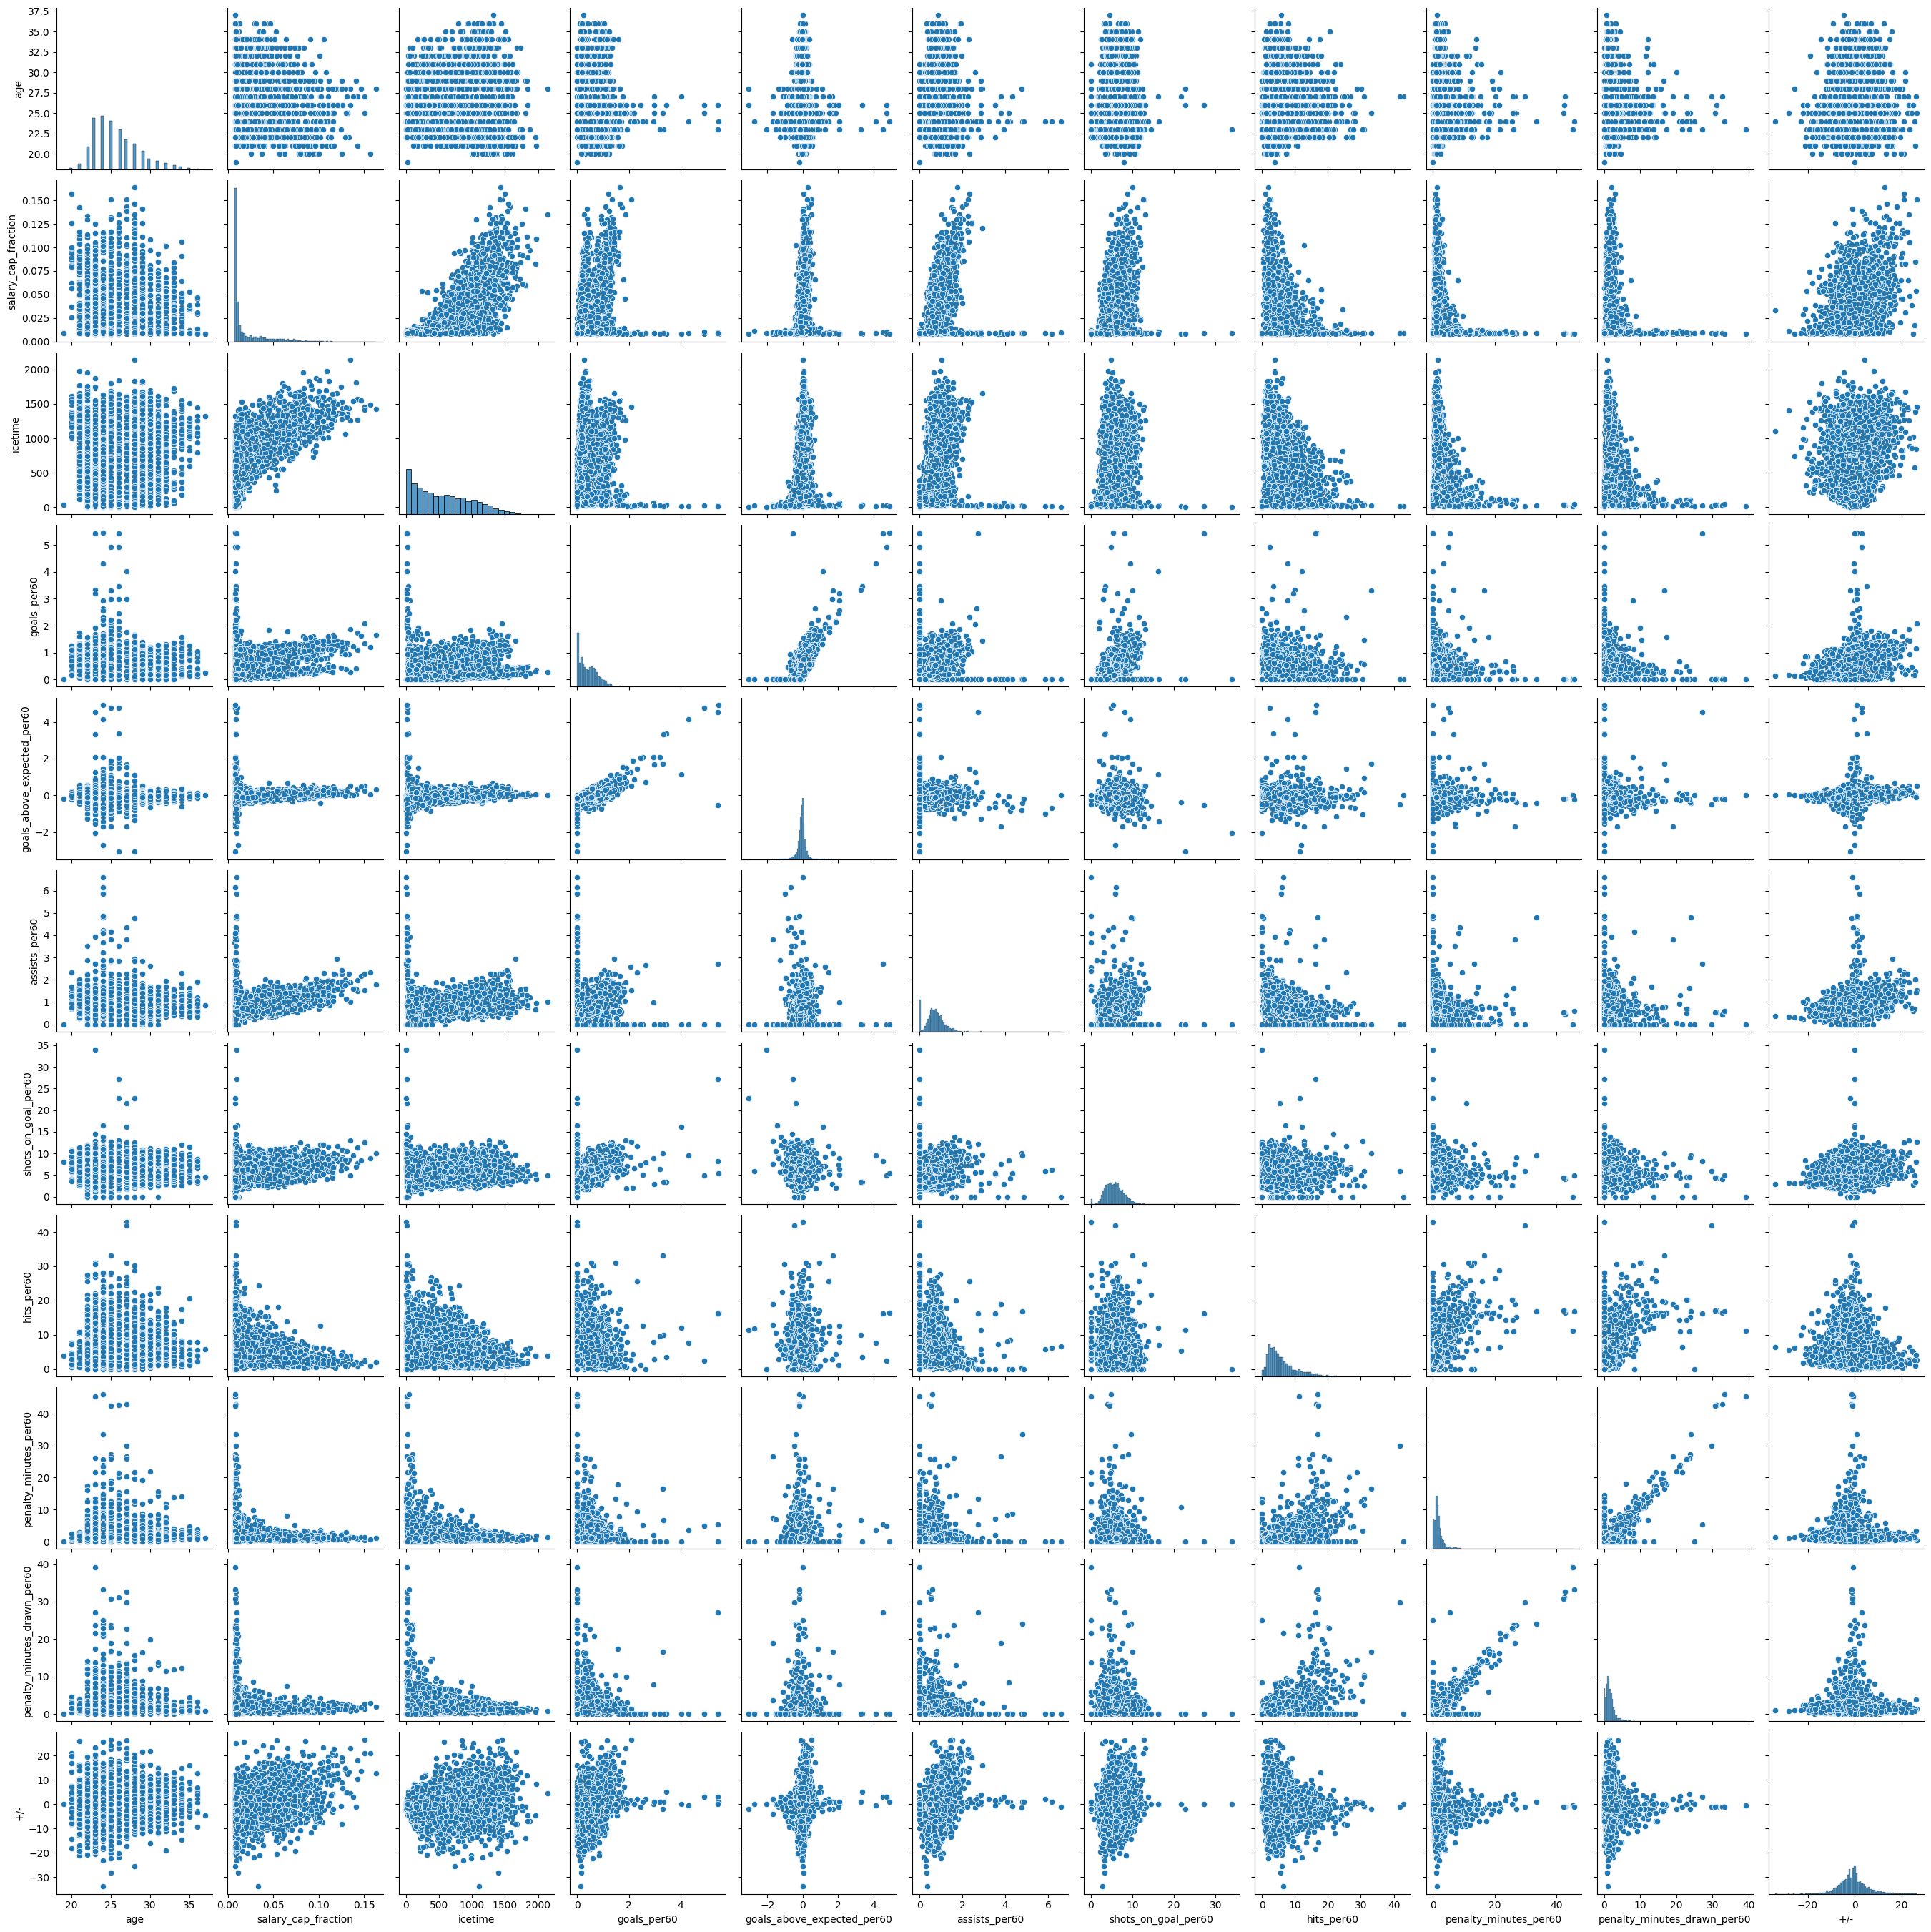

In [12]:
sns.pairplot(correlation_frame)

We see that there are a lot of outliers for players with low icetime when looking at correlation with other stats. However, the most important thing, that is correlation with salary_cap_fraction, does not seem to suffer from these. Players with low icetime do not make much money, which is what we are trying to predict. Thus I do not think we need to implement a cut on player icetime to make the stats more reliable, as low icetime itself should be a good predictor for the player salary.

We are now at a point where our initial choice of features look like a reasonable guess. So let's split our features and target variables into training and testing sets and start training some models. Let's first do simple linear regression and XGBoost.

In [13]:
# Use 75% of the data for training and 25% for testing
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.25, random_state=42)

# Produce scaled versions of the features
# This is important for neural networks but makes negligible difference for linear regression or XGBoost
scaler = StandardScaler()
features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)

# Train a linear regression model with the training data
simple_regression = LinearRegression().fit(features_train, target_train)

# Do teh same with scaled data
scaled_regression = LinearRegression().fit(features_train_scaled, target_train)

# Print the R^2 score for training and testing sets
print("Linear regression: R^2 score on training data: {}".format(simple_regression.score(features_train, target_train)))
print("Linear regression: R^2 score on testing data: {}".format(simple_regression.score(features_test, target_test)))
print("Scaled regression: R^2 score on training data: {}".format(scaled_regression.score(features_train_scaled, target_train)))
print("Scaled regression: R^2 score on testing data: {}".format(scaled_regression.score(features_test_scaled, target_test)))

# Do the same with xgboost
gradient_boost = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
scaled_xgboost = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)

gradient_boost.fit(features_train, target_train)
boosted_prediction_train = gradient_boost.predict(features_train)
boosted_prediction = gradient_boost.predict(features_test)

scaled_xgboost.fit(features_train_scaled, target_train)
scaled_xgboost_prediction_train = scaled_xgboost.predict(features_train_scaled)
scaled_xgboost_prediction = scaled_xgboost.predict(features_test_scaled)

print("XGBoost: R^2 score on training data: {}".format(r2_score(target_train, boosted_prediction_train)))
print("XGBoost: R^2 score on testing data: {}".format(r2_score(target_test, boosted_prediction)))
print("Scaled XGBoost: R^2 score on training data: {}".format(r2_score(target_train, scaled_xgboost_prediction_train)))
print("Scaled XGBoost: R^2 score on testing data: {}".format(r2_score(target_test, scaled_xgboost_prediction)))

Linear regression: R^2 score on training data: 0.6725095703510007
Linear regression: R^2 score on testing data: 0.6641324908048275
Scaled regression: R^2 score on training data: 0.6725095703510007
Scaled regression: R^2 score on testing data: 0.6641324908048276
XGBoost: R^2 score on training data: 0.9958491442049998
XGBoost: R^2 score on testing data: 0.831733339738087
Scaled XGBoost: R^2 score on training data: 0.9958491442049998
Scaled XGBoost: R^2 score on testing data: 0.831733339738087


The R^2 scores are not super great for linear regression. They are better for XGBoost, even though there is quite a discrepancy between the scores for testing and training data. Let's also evaluate the performance visually by looking at the kernel density distributions for predictions and residuals.

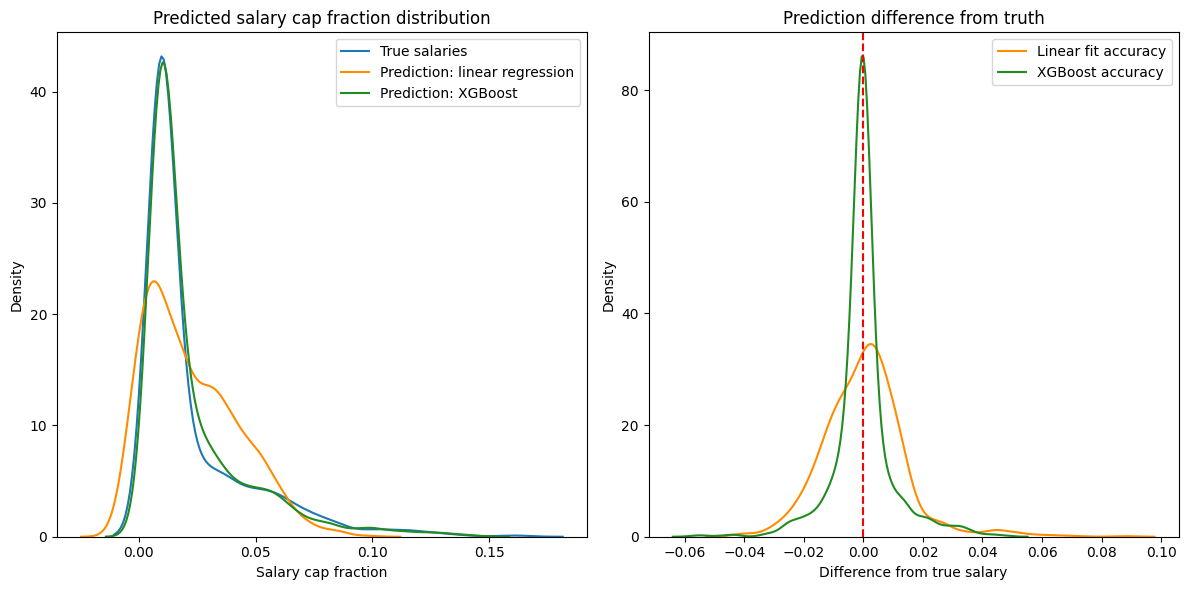

In [14]:
# Get the prediction also for the linear model
linear_prediction = simple_regression.predict(features_test)

# Calculate the residuals
numpy_salary = np.array(target_test)
numpy_linear_prediction = np.array(linear_prediction)
numpy_xgboost_prediction = np.array(boosted_prediction)
linear_residual = numpy_salary - numpy_linear_prediction
xgboost_residual = numpy_salary - numpy_xgboost_prediction

# Plot the kernel density functions

# Define consistent colors for plotting
color = {"linear": "darkorange", "xgboost": "forestgreen"}

#Figure
fig=plt.figure(figsize=(12, 6))
    
#Create different axes for subploting
ax0 = fig.add_subplot(1, 2, 1) # add subplot 1 (1 row, 2 columns, first plot)
ax1 = fig.add_subplot(1 ,2, 2) # add subplot 2 (1 row, 2 columns, second plot). 
    
#plt.subplot(1, 2, 1)
sns.kdeplot(x=target_test, ax=ax0, label='True salaries')
sns.kdeplot(x=linear_prediction, ax=ax0, label='Prediction: linear regression', color=color["linear"])
sns.kdeplot(x=boosted_prediction, ax=ax0, label='Prediction: XGBoost', color=color["xgboost"])
ax0.set_xlabel('Salary cap fraction')
ax0.set_ylabel('Density')
ax0.set_title('Predicted salary cap fraction distribution')
ax0.legend()

#plt.subplot(1, 2, 2)
sns.kdeplot(x=linear_residual, ax=ax1, label='Linear fit accuracy', color=color["linear"])
sns.kdeplot(x=xgboost_residual, ax=ax1, label='XGBoost accuracy', color=color["xgboost"])
ax1.axvline(x=0, color='red', linestyle='--')
ax1.set_xlabel('Difference from true salary')
ax1.set_ylabel('Density')
ax1.set_title('Prediction difference from truth')
ax1.legend()
    
plt.tight_layout()
plt.show()

From the visual inspection we can see that XGBoost gets the low salary peak really well, but struggles a bit on the high salary end. There are also some wiggles in the prediction at the high end, which might be signs of overfitting. Still, this is an encouraging start!

Before continuing, let's visualize feature importances for XGBoost to see what is actually used for the prediction.

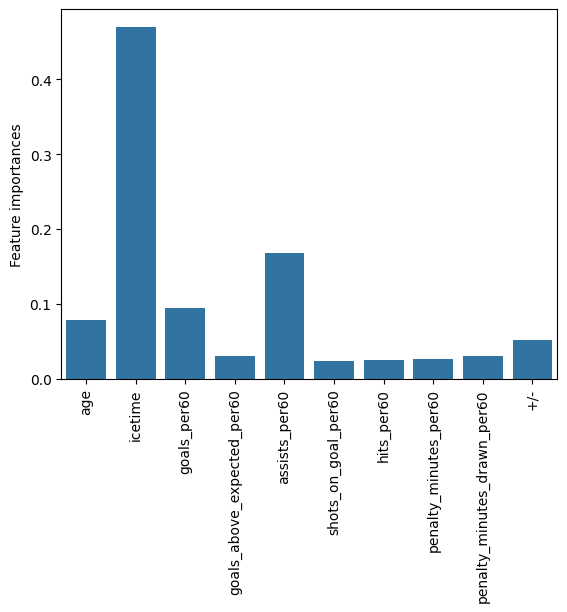

In [15]:
# Access feature importance scores
importance_scores = gradient_boost.feature_importances_

# Make a bar plot with seaborn to visualize the feature importances
sns.barplot(x=features.columns.tolist(), y=importance_scores)
plt.ylabel("Feature importances")
plt.xticks(rotation=90)
plt.show()

As expected from the correlation matrix we exemined earlier, icetime is the strongest predictor for contract value, followed by point production, age, and +/- score. We can use this information later to try to remove unimportant features from the model and maybe add some other features that might have better predictive power. There are a lot of possible features in the stats tables we are not using at the moment.

Let's switch gears and see if we can train a neural network to do better job. For the sake of example, we will make the network with both Keras and PyTorch, and see if there are any differences between the predictions. Finally, we can compare all predictions together. First, let's implement the model with Keras.

In [16]:
# We can start with a small network that takes the input variables and has two hidden dense layers

# Define the input layer
input_layer = Input(shape=(features_train_scaled.shape[1],))

# Add a hidden layer with 64 neurons
hidden_layer = Dense(64, activation='relu')(input_layer)

# Add another hidden layer with 32 neurons
hidden_layer2 = Dense(32, activation='relu')(hidden_layer)

# Define the output layer
output_layer = Dense(1, activation='linear')(hidden_layer2)

# Create the model
keras_model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model and print out summary
keras_model.compile(optimizer='adam', loss='mean_squared_error')
keras_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

Once we have our neural network defined, fit it to the training data and test it with test data.

In [17]:
keras_model.fit(features_train_scaled, target_train, validation_split=0.25, epochs=100, verbose=2, batch_size=32)

Epoch 1/100
76/76 - 1s - 7ms/step - loss: 0.0213 - val_loss: 0.0068
Epoch 2/100
76/76 - 0s - 604us/step - loss: 0.0043 - val_loss: 0.0046
Epoch 3/100
76/76 - 0s - 595us/step - loss: 0.0028 - val_loss: 0.0034
Epoch 4/100
76/76 - 0s - 594us/step - loss: 0.0022 - val_loss: 0.0025
Epoch 5/100
76/76 - 0s - 581us/step - loss: 0.0015 - val_loss: 0.0019
Epoch 6/100
76/76 - 0s - 589us/step - loss: 0.0012 - val_loss: 0.0016
Epoch 7/100
76/76 - 0s - 596us/step - loss: 0.0011 - val_loss: 0.0014
Epoch 8/100
76/76 - 0s - 602us/step - loss: 9.0063e-04 - val_loss: 0.0013
Epoch 9/100
76/76 - 0s - 590us/step - loss: 7.8584e-04 - val_loss: 0.0012
Epoch 10/100
76/76 - 0s - 593us/step - loss: 7.0218e-04 - val_loss: 0.0012
Epoch 11/100
76/76 - 0s - 586us/step - loss: 6.9843e-04 - val_loss: 0.0010
Epoch 12/100
76/76 - 0s - 579us/step - loss: 6.5077e-04 - val_loss: 0.0011
Epoch 13/100
76/76 - 0s - 582us/step - loss: 5.9713e-04 - val_loss: 0.0010
Epoch 14/100
76/76 - 0s - 579us/step - loss: 5.6678e-04 - val_lo

In [18]:
keras_prediction_train = keras_model.predict(features_train_scaled).flatten()
keras_prediction = keras_model.predict(features_test_scaled).flatten()

print("Keras: R^2 score on training data: {}".format(r2_score(target_train, keras_prediction_train)))
print("Keras: R^2 score on testing data: {}".format(r2_score(target_test, keras_prediction)))

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step
Keras: R^2 score on training data: 0.8296380530826163
Keras: R^2 score on testing data: 0.7182024342979709


The R^2 scores we get seem reasonable and are between the predictions obtained from simple linear regression and XGBoost. Let's change the neural network architecture a bit to see if we can improve. Let's also make the implementation with PyTorch in order to showcase how to implement a neural network with different machinery. We start by converting the feature and target data into a format PyTorch can consume.

In [19]:
# Create a class to handle data feeding for PyTorch. The class inherits from Dataset class
class PlayerDataset(Dataset):
    def __init__(self, features, target):
        self.features = torch.from_numpy(features).float()
        self.target = torch.from_numpy(target.to_numpy().copy()).float().unsqueeze(1)
        
    def __getitem__(self,index):        
        return self.features[index], self.target[index]
        
    def __len__(self):
        return len(self.features)

In [20]:
# Create a class that defines the neural network structure in PyTorch
class PlayerNetwork(nn.Module):
    def __init__(self,input_dimension,hidden1,hidden2):
        super(PlayerNetwork,self).__init__()
        self.linear1=nn.Linear(input_dimension,hidden1)
        self.relu1 = nn.ReLU()
        self.linear2=nn.Linear(hidden1,hidden2)
        self.relu2 = nn.ReLU()
        self.linear3=nn.Linear(hidden2,1)
        
    def forward(self,x):
        x = self.relu1(self.linear1(x))
        x = self.relu2(self.linear2(x))
        x = self.linear3(x)
        return x

In [40]:
# Create datasets and instantiate the network
tensor_train_data = PlayerDataset(features_train_scaled, target_train)
tensor_test_data = PlayerDataset(features_test_scaled, target_test)
pytorch_model = PlayerNetwork(features_train_scaled.shape[1],64,32)

# Define criterion for the loss function and optimizer
learning_rate = 0.001
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(pytorch_model.parameters(), lr=learning_rate)
train_loader = DataLoader(dataset=tensor_train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=tensor_test_data, batch_size=128, shuffle=False)

In [41]:
# Write a training loop for the PyTorch model
nEpoch = 100
cost=[]

# Put the model to training mode
pytorch_model.train()

for epoch in range(nEpoch):

    # Initialize the total cost to 0
    total_cost=0

    # Load the training data in batches
    for x,y in train_loader:

        # Clear the gradients from previous iteration
        optimizer.zero_grad()

        # Make a forward pass through the model
        yhat=pytorch_model(x)

        # Calculate the loss based on the forward pass
        loss=criterion(yhat,y)

        # Prepare the gradients by making a backward pass
        loss.backward()

        # Update the model weights based on calculated gradients
        optimizer.step()

        # Add the loss from this batch to the total cost value
        total_cost+=loss.item()
            
    # Append the total cost from this epoch to the cost array   
    cost.append(total_cost)

In [44]:
# Make predictions with the model using test dataset
# Start by putting the model to evaluation mode
pytorch_model.eval()

# Make predictions and collect them into a single numpy array
all_predictions = []
with torch.no_grad():
    for x, y in test_loader:
        yhat = pytorch_model(x)
        all_predictions.append(yhat.cpu().numpy())
pytorch_prediction = np.concatenate(all_predictions, axis=0)

# Squeeze the predictions into one dimension
pytorch_prediction = pytorch_prediction.squeeze()

# Calculate the R^2 score of the prediction
print("PyTorch: R^2 score on testing data: {}".format(r2_score(target_test, pytorch_prediction)))


PyTorch: R^2 score on testing data: 0.8219372300606694


This is the same network as with Keras, so similar R^2 score makes sense. Let's plot all the models to the same plot.

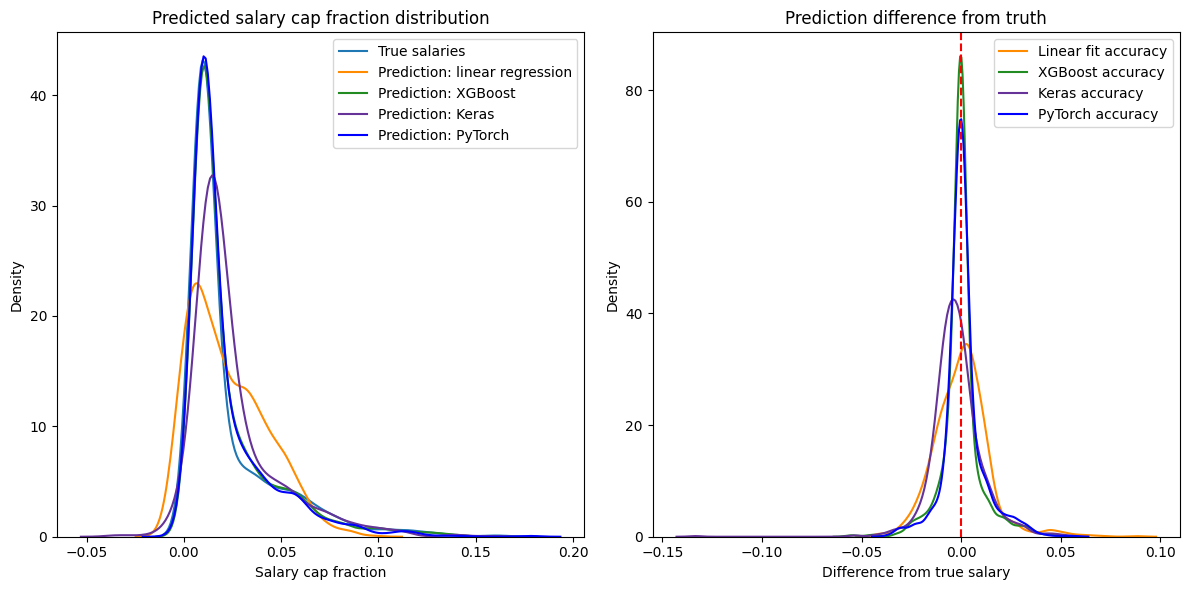

In [45]:
# Calculate the residuals
keras_residual = numpy_salary - keras_prediction
pytorch_residual = numpy_salary - pytorch_prediction

# Plot the kernel density functions

# Define consistent colors for plotting
color = {"linear": "darkorange", "xgboost": "forestgreen", "keras": "rebeccapurple", "pytorch": "blue"}

#Figure
fig=plt.figure(figsize=(12, 6))
    
#Create different axes for subploting
ax0 = fig.add_subplot(1, 2, 1) # add subplot 1 (1 row, 2 columns, first plot)
ax1 = fig.add_subplot(1 ,2, 2) # add subplot 2 (1 row, 2 columns, second plot). 
    
#plt.subplot(1, 2, 1)
sns.kdeplot(x=target_test, ax=ax0, label='True salaries')
sns.kdeplot(x=linear_prediction, ax=ax0, label='Prediction: linear regression', color=color["linear"])
sns.kdeplot(x=boosted_prediction, ax=ax0, label='Prediction: XGBoost', color=color["xgboost"])
sns.kdeplot(x=keras_prediction, ax=ax0, label='Prediction: Keras', color=color["keras"])
sns.kdeplot(x=pytorch_prediction, ax=ax0, label='Prediction: PyTorch', color=color["pytorch"])
ax0.set_xlabel('Salary cap fraction')
ax0.set_ylabel('Density')
ax0.set_title('Predicted salary cap fraction distribution')
ax0.legend()

#plt.subplot(1, 2, 2)
sns.kdeplot(x=linear_residual, ax=ax1, label='Linear fit accuracy', color=color["linear"])
sns.kdeplot(x=xgboost_residual, ax=ax1, label='XGBoost accuracy', color=color["xgboost"])
sns.kdeplot(x=keras_residual, ax=ax1, label='Keras accuracy', color=color["keras"])
sns.kdeplot(x=pytorch_residual, ax=ax1, label='PyTorch accuracy', color=color["pytorch"])
ax1.axvline(x=0, color='red', linestyle='--')
ax1.set_xlabel('Difference from true salary')
ax1.set_ylabel('Density')
ax1.set_title('Prediction difference from truth')
ax1.legend()
    
plt.tight_layout()
plt.show()